<a href="https://colab.research.google.com/github/Aisyahnov/Aisyahnov/blob/main/GuidebookDigilearnBD26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd
import numpy as np
from scipy import stats

# MEMBUAT DATASET LENGKAP (30 BARIS)
data = {
    'nama': ['Agus', 'Budi', 'Citra', 'Dedi', 'Euis', 'Fajar', 'Gani', 'Hani', 'Indra', 'Joko',
             'Kartika', 'Lina', 'Mega', 'Nina', 'Oki', 'Putra', 'Qori', 'Rian', 'Sari', 'Tono',
             'Uli', 'Vina', 'Wawan', 'Xena', 'Yanto', 'Zaki', 'Amel', 'Bambang', 'Caca', 'Dodo'],
    'jenis_kelamin': ['Laki-laki', 'Laki-laki', 'Perempuan', 'Laki-laki', 'Perempuan',
                      'Perempuan', 'Laki-laki', 'Perempuan', 'Laki-laki', 'Laki-laki',
                      'Perempuan', 'Perempuan', 'Perempuan', 'Perempuan', 'Laki-laki',
                      'Laki-laki', 'Perempuan', 'Laki-laki', 'Perempuan', 'Laki-laki',
                      'Perempuan', 'Perempuan', 'Laki-laki', 'Perempuan', 'Laki-laki',
                      'Laki-laki', 'Perempuan', 'Laki-laki', 'Perempuan', 'Laki-laki'],
    'usia': ['20', '21', '22', '21', '20', '21', '20', '22', '20', '21',
             '20', '21', '22', '21', '150', '22', '21', '23', '20', '22',
             '21', '20', '22', '21', '20', '21', '22', '21', '20', '21'], # Outlier 150
    'ipk': [3.5, 4.0, 3.8, 3.2, 3.9, 3.6, 2.5, 3.7, 3.8, 3.5,
            3.6, 3.8, 3.1, 4.0, 3.0, 3.4, 3.7, 3.2, 3.2, 3.5,
            3.8, 3.9, 3.1, 3.6, 3.4, 3.2, 3.7, 3.5, 3.8, 3.3], # Ada Null
    'sks': [20, 22, 24, 21, 24, 23, 10, 22, 20, 21,
            24, 22, 21, 20, 18, 22, 21, 20, 23, 22,
            24, 21, 20, 22, 21, 23, 20, 22, 22, 21], # Ada Null
    'tahun_masuk': [2024, 2023, 2022, 2023, 2024, 2023, 2024, 2022, 2024, 2023,
                    2024, 2023, 2022, 2023, 2024, 2023, 2024, 2022, 2024, 2023,
                    2024, 2023, 2024, 2023, 2024, 2023, 2024, 2023, 2024, 2023],
    'jurusan': ['Sistem Informasi', 'Sistem Informasi', 'Manajemen', 'Akuntansi', 'Teknik Elektro',
                'Psikologi', 'Teknik Sipil', 'Hukum', 'Kedokteran', 'Farmasi',
                'Seni Rupa', 'Sistem Informasi', 'Desain Grafis', 'Arsitektur', 'Matematika',
                'Informatika', 'Sistem Informasi', 'Manajemen', 'Akuntansi', 'Hukum',
                'Psikologi', 'Teknik Sipil', 'Sistem Informasi', 'Informatika', 'Manajemen',
                'Sistem Informasi', 'Akuntansi', 'Hukum', 'Sistem Informasi', 'Manajemen'],
    'status': ['Aktif']*30
}

df = pd.DataFrame(data)


In [6]:
df.head()

,nama,jenis_kelamin,usia,ipk,sks,tahun_masuk,jurusan,status
0,Agus,Laki-laki,20,3.5,20.0,2024,Sistem Informasi,Aktif
1,Budi,Laki-laki,21,NaN,22.0,2023,Sistem Informasi,Aktif
2,Citra,Perempuan,22,3.8,24.0,2022,Manajemen,Aktif
3,Dedi,Laki-laki,21,3.2,21.0,2023,Akuntansi,Aktif
4,Euis,Perempuan,20,3.9,NaN,2024,Teknik Elektro,Aktif


HANDLING NULL VALUES

In [15]:
# Checking Null
print(df.isnull().sum())

nama             0
jenis_kelamin    0
usia             0
ipk              2
sks              2
tahun_masuk      0
jurusan          0
status           0
dtype: int64


In [19]:
# Data Deletion
df_deleted = df.dropna()
print(df.isnull().sum())

nama             0
jenis_kelamin    0
usia             0
ipk              2
sks              2
tahun_masuk      0
jurusan          0
status           0
dtype: int64


In [17]:
# Data Imputation
df['ipk'] = df['ipk'].fillna(df['ipk'].mean())
df['sks'] = df['sks'].fillna(df['sks'].median())
print(df.isnull().sum())

nama             0
jenis_kelamin    0
usia             0
ipk              0
sks              0
tahun_masuk      0
jurusan          0
status           0
dtype: int64


HANDLING OUTLIERS

In [21]:
df['usia'] = pd.to_numeric(df['usia']) # Persiapan untuk kalkulasi

Q1 = df['usia'].quantile(0.25)
Q3 = df['usia'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove
df = df[(df['usia'] >= lower_bound) & (df['usia'] <= upper_bound)]

# Transform
df['usia_log'] = np.log1p(df['usia'])

# Cap/Floor
df['usia'] = np.where(df['usia'] > upper_bound, upper_bound,
             np.where(df['usia'] < lower_bound, lower_bound, df['usia']))

# Imputation
df.loc[df['usia'] > upper_bound, 'usia'] = df['usia'].median()

print(f"Data setelah Cap/Floor (Usia Baris Terakhir): {df['usia'].iloc[14]}")

Data setelah Cap/Floor (Usia Baris Terakhir): 22.0



CHECKING DATA TYPES
---



In [22]:
print("Tipe Data Saat Ini:")
print(df.dtypes)

df['usia'] = df['usia'].astype(int)
print("Tipe Data Setelah Perbaikan:")
print(df.dtypes)

Tipe Data Saat Ini:
nama              object
jenis_kelamin     object
usia             float64
ipk              float64
sks              float64
tahun_masuk        int64
jurusan           object
status            object
usia_log         float64
dtype: object
Tipe Data Setelah Perbaikan:
nama              object
jenis_kelamin     object
usia               int64
ipk              float64
sks              float64
tahun_masuk        int64
jurusan           object
status            object
usia_log         float64
dtype: object


DROPPING IRRELEVANT COLUMNS

In [23]:
print(f"Kolom Sebelum Drop: {df.columns.tolist()}")

# Menghapus kolom 'status' (konstan/tidak relevan)
df.drop(columns=['status'], inplace=True)

print(f"Kolom Setelah Drop: {df.columns.tolist()}")

Kolom Sebelum Drop: ['nama', 'jenis_kelamin', 'usia', 'ipk', 'sks', 'tahun_masuk', 'jurusan', 'status', 'usia_log']
Kolom Setelah Drop: ['nama', 'jenis_kelamin', 'usia', 'ipk', 'sks', 'tahun_masuk', 'jurusan', 'usia_log']


# 2. PREPROCESSING

In [24]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, LabelEncoder, OrdinalEncoder
from sklearn.utils import resample

In [28]:
from google.colab import data_table
data_table.enable_dataframe_formatter()

In [29]:
numerical_cols = ['usia', 'ipk', 'sks']

SCALING

In [35]:
# Min-Max Scaling
min_max_scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[numerical_cols] = min_max_scaler.fit_transform(df[numerical_cols])
print("Hasil Min-Max Scaling (5 Baris):\n", df_minmax[numerical_cols].head())

# Standard Scaling
std_scaler = StandardScaler()
df_std = df.copy()
df_std[numerical_cols] = std_scaler.fit_transform(df[numerical_cols])
print("\nHasil Standard Scaling (5 Baris):\n", df_std[numerical_cols].head())

# Robust Scaling
robust_scaler = RobustScaler()
df_robust = df.copy()
df_robust[numerical_cols] = robust_scaler.fit_transform(df[numerical_cols])
print("\nHasil Robust Scaling (5 Baris):\n", df_robust[numerical_cols].head())

Hasil Min-Max Scaling (5 Baris):
        usia       ipk       sks
0  0.000000  0.666667  0.714286
1  0.007692  1.000000  0.857143
2  0.015385  0.866667  1.000000
3  0.007692  0.466667  0.785714
4  0.000000  0.933333  1.000000

Hasil Standard Scaling (5 Baris):
        usia       ipk       sks
0 -0.228738 -0.029674 -0.475831
1 -0.185580  1.454021  0.317221
2 -0.142422  0.860543  1.110272
3 -0.185580 -0.919891 -0.079305
4 -0.228738  1.157282  1.110272

Hasil Robust Scaling (5 Baris):
    usia       ipk       sks
0  -0.5 -0.086957 -0.857143
1   0.0  0.782609  0.285714
2   0.5  0.434783  1.428571
3   0.0 -0.608696 -0.285714
4  -0.5  0.608696  1.428571


In [36]:
# Simulasi Dataset Tidak Seimbang
minority = df[df['jenis_kelamin'] == 'Perempuan']
majority = df[df['jenis_kelamin'] == 'Laki-laki']

# Oversampling
minority_upsampled = resample(minority, replace=True, n_samples=len(majority),
                              random_state=42)
df_oversampled = pd.concat([majority, minority_upsampled])
print(f"Jumlah baris setelah Oversampling: {len(df_oversampled)}")

# Undersampling
majority_downsampled = resample(majority, replace=False, n_samples=len(minority),
                                random_state=42)
df_undersampled = pd.concat([majority_downsampled, minority])
print(f"Jumlah baris setelah Undersampling: {len(df_undersampled)}")

# Random Sampling
df_random = df.sample(n=10, random_state=42)
print(f"Jumlah baris setelah Random Sampling: {len(df_random)}")

Jumlah baris setelah Oversampling: 30
Jumlah baris setelah Undersampling: 30
Jumlah baris setelah Random Sampling: 10


In [38]:
# Feature Selection
df_ml = df.drop(columns=['nama'])
print("Kolom setelah Feature Selection:", df_ml.columns.tolist())

# Feature Creation
df['ipk_per_sks'] = df['ipk'] / df['sks']
print("Fitur Baru 'ipk_per_sks' Berhasil Dibuat.")

# Feature Splitting
df['nama_depan'] = df['nama'].str.split().str[0]
print("Fitur 'nama_depan' Berhasil Dipecah dari 'nama'.")

Kolom setelah Feature Selection: ['jenis_kelamin', 'usia', 'ipk', 'sks', 'tahun_masuk', 'jurusan', 'status', 'ipk_per_sks', 'nama_depan']
Fitur Baru 'ipk_per_sks' Berhasil Dibuat.
Fitur 'nama_depan' Berhasil Dipecah dari 'nama'.


In [40]:
# Label Encoding
le = LabelEncoder()
df['jk_label'] = le.fit_transform(df['jenis_kelamin'])
print("Hasil Label Encoding (Jenis Kelamin):\n", df[['jenis_kelamin', 'jk_label']].head())

# One-Hot Encoding
df_ohe = pd.get_dummies(df, columns=['jurusan'], prefix='jurusan')
print("\nKolom hasil One-Hot Encoding:\n", [col for col in df_ohe.columns if 'jurusan_' in col][:5])

# Ordinal Encoding
oe = OrdinalEncoder(categories=[sorted(df['tahun_masuk'].unique())])
df['tahun_ordinal'] = oe.fit_transform(df[['tahun_masuk']])
print("\nHasil Ordinal Encoding (Tahun Masuk):\n", df[['tahun_masuk', 'tahun_ordinal']].head())

Hasil Label Encoding (Jenis Kelamin):
   jenis_kelamin  jk_label
0     Laki-laki         0
1     Laki-laki         0
2     Perempuan         1
3     Laki-laki         0
4     Perempuan         1

Kolom hasil One-Hot Encoding:
 ['jurusan_Akuntansi', 'jurusan_Arsitektur', 'jurusan_Desain Grafis', 'jurusan_Farmasi', 'jurusan_Hukum']

Hasil Ordinal Encoding (Tahun Masuk):
    tahun_masuk  tahun_ordinal
0         2024            2.0
1         2023            1.0
2         2022            0.0
3         2023            1.0
4         2024            2.0


/tmp/ipykernel_20179/2363243319.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='jurusan', palette='viridis')


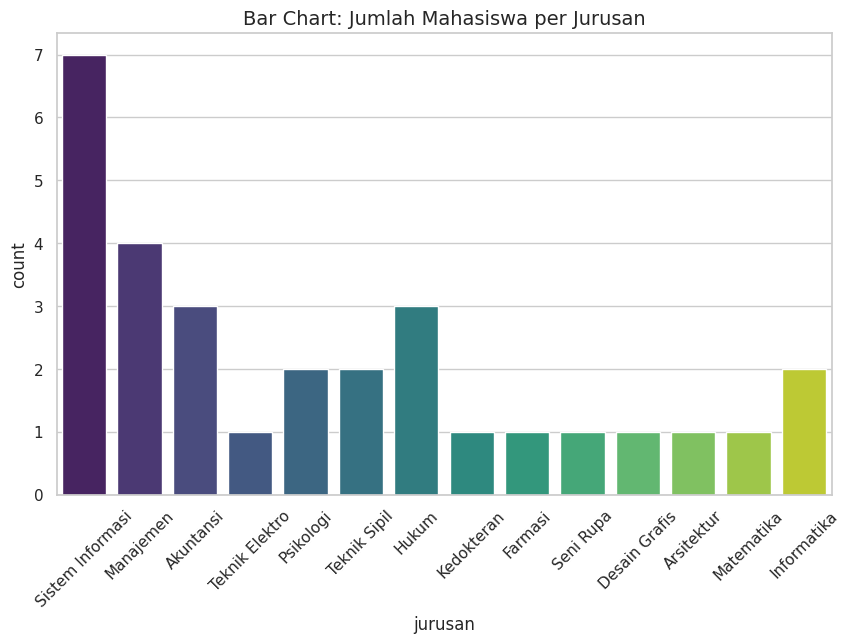

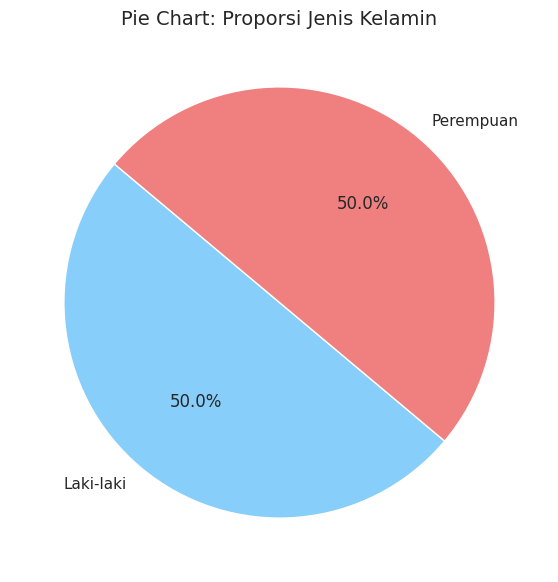

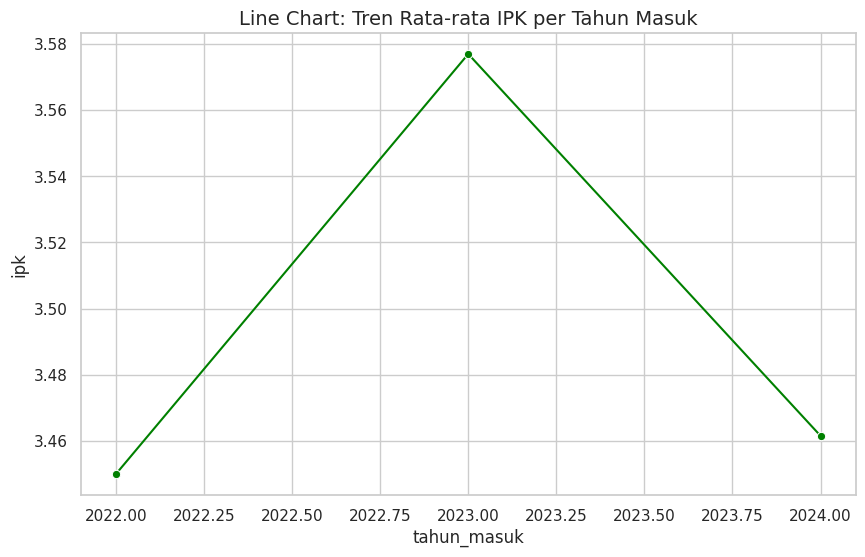

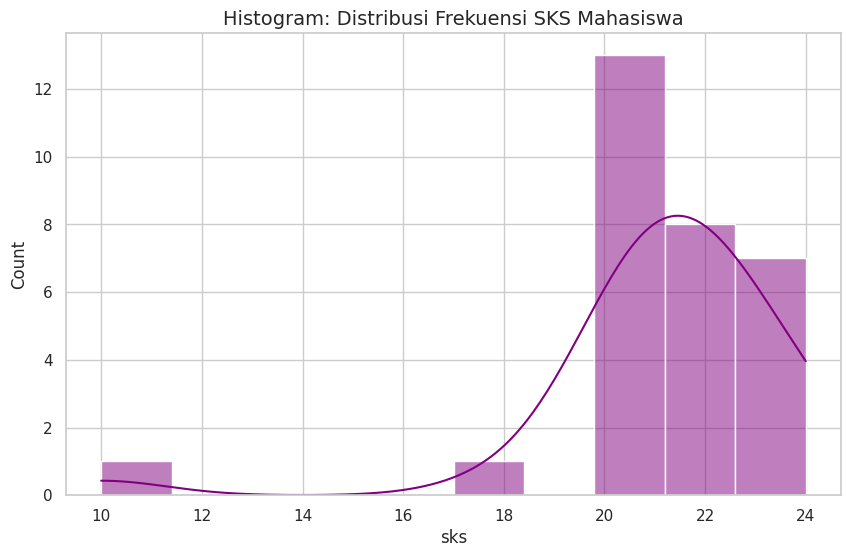

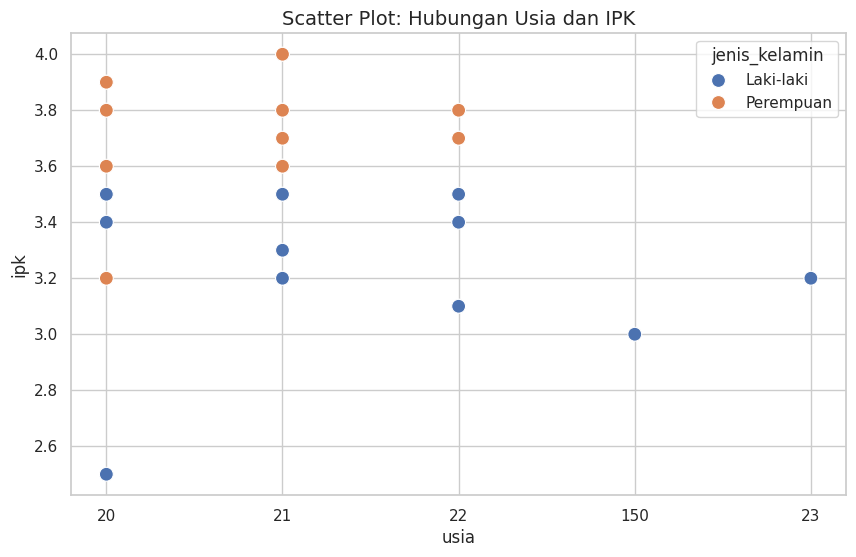

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tema visualisasi agar lebih estetik
sns.set_theme(style="whitegrid")

# =================================================================
# 1. BAR CHART
# =================================================================
# Menampilkan perbandingan nilai antar kategori (Misal: Jumlah Mahasiswa per Jurusan)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='jurusan', palette='viridis')
plt.title('Bar Chart: Jumlah Mahasiswa per Jurusan', fontsize=14)
plt.xticks(rotation=45)
plt.show()

# =================================================================
# 2. PIE CHART
# =================================================================
# Menampilkan proporsi data (Misal: Persentase Jenis Kelamin)
plt.figure(figsize=(7, 7))
gender_counts = df['jenis_kelamin'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
        colors=['lightskyblue', 'lightcoral'], startangle=140)
plt.title('Pie Chart: Proporsi Jenis Kelamin', fontsize=14)
plt.show()

# =================================================================
# 3. LINE CHART
# =================================================================
# Menampilkan tren (Misal: Rata-rata IPK berdasarkan Tahun Masuk)
plt.figure(figsize=(10, 6))
trend_data = df.groupby('tahun_masuk')['ipk'].mean().reset_index()
sns.lineplot(data=trend_data, x='tahun_masuk', y='ipk', marker='o', color='green')
plt.title('Line Chart: Tren Rata-rata IPK per Tahun Masuk', fontsize=14)
plt.show()

# =================================================================
# 4. HISTOGRAM
# =================================================================
# Menampilkan sebaran frekuensi data numerik (Misal: Distribusi SKS)
plt.figure(figsize=(10, 6))
sns.histplot(df['sks'], bins=10, kde=True, color='purple')
plt.title('Histogram: Distribusi Frekuensi SKS Mahasiswa', fontsize=14)
plt.show()

# =================================================================
# 5. SCATTER PLOT
# =================================================================
# Memetakan hubungan antar dua variabel (Misal: Hubungan Usia dan IPK)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='usia', y='ipk', hue='jenis_kelamin', s=100)
plt.title('Scatter Plot: Hubungan Usia dan IPK', fontsize=14)
plt.show()

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- PERSIAPAN FITUR & TARGET ---
# Asumsi: Kita memprediksi 'jk_label' berdasarkan fitur numerik dan jurusan yang sudah di-encode
X = df_ml.drop(columns=['jk_label'])
y = df_ml['jk_label']

# =================================================================
# 1. SPLITTING DATA
# =================================================================
# Membagi dataset menjadi data training dan data testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Step 1: Splitting Data ---")
print(f"Jumlah Data Training: {len(X_train)}")
print(f"Jumlah Data Testing: {len(X_test)}")

# =================================================================
# 2. MODEL SELECTION
# =================================================================
# Memilih algoritma Supervised Learning - Classification (Logistic Regression)
model = LogisticRegression()
print("\n--- Step 2: Model Selection ---")
print("Model: Logistic Regression")

# =================================================================
# 3. TRAINING MODEL
# =================================================================
# Mengajarkan model untuk mempelajari pola dari data training
model.fit(X_train, y_train)
print("\n--- Step 3: Training Model ---")
print("Status: Model successfully trained.")

# =================================================================
# 4. TESTING MODEL
# =================================================================
# Mengevaluasi performa pada data yang belum pernah dilihat (data testing)
y_pred = model.predict(X_test)
print("\n--- Step 4: Testing Model ---")
print("Status: Prediction completed.")

# =================================================================
# 5. EVALUATION
# =================================================================
print("\n--- Step 5: Evaluation (Metrics) ---")

# Menghitung metrik evaluasi sesuai draf Bab 4
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {acc:.2f} (Persentase prediksi benar)")
print(f"Precision : {prec:.2f} (Ketepatan prediksi positif)")
print(f"Recall    : {rec:.2f} (Kemampuan mendeteksi kelas positif)")
print(f"F1-Score  : {f1:.2f} (Rata-rata harmonis Precision & Recall)")

# Visualisasi Confusion Matrix untuk melengkapi laporan
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix Evaluation')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

KeyError: "['jk_label'] not found in axis"